In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://books.toscrape.com/"

In [3]:
response = requests.get(url)

print(response.status_code)

200


In [4]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [5]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [6]:
titles = []

for book in books:
    title = book.h3.a["title"]
    titles.append(title)

print(titles)

['A Light in the Attic', 'Tipping the Velvet', 'Soumission', 'Sharp Objects', 'Sapiens: A Brief History of Humankind', 'The Requiem Red', 'The Dirty Little Secrets of Getting Your Dream Job', 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'The Black Maria', 'Starving Hearts (Triangular Trade Trilogy, #1)', "Shakespeare's Sonnets", 'Set Me Free', "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)", 'Rip it Up and Start Again', 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991', 'Olio', 'Mesaerion: The Best Science Fiction Stories 1800-1849', 'Libertarianism for Beginners', "It's Only the Himalayas"]


In [7]:
prices = []

for book in books:
    price = book.find("p", class_="price_color").text
    prices.append(price)

print(prices)

['Â£51.77', 'Â£53.74', 'Â£50.10', 'Â£47.82', 'Â£54.23', 'Â£22.65', 'Â£33.34', 'Â£17.93', 'Â£22.60', 'Â£52.15', 'Â£13.99', 'Â£20.66', 'Â£17.46', 'Â£52.29', 'Â£35.02', 'Â£57.25', 'Â£23.88', 'Â£37.59', 'Â£51.33', 'Â£45.17']


In [8]:
availability = []

for book in books:
    stock = book.find("p", class_="instock availability").text.strip()
    availability.append(stock)

print(availability)

['In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock', 'In stock']


In [9]:
df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Availability": availability
})

df.head()

,Title,Price,Availability
0,A Light in the Attic,Â£51.77,In stock
1,Tipping the Velvet,Â£53.74,In stock
2,Soumission,Â£50.10,In stock
3,Sharp Objects,Â£47.82,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock


In [10]:
df.shape

(20, 3)

In [11]:
df.isnull().sum()

Title           0
Price           0
Availability    0
dtype: int64

In [13]:
df["Price"] = df["Price"].str.replace(r"[^\d.]", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"])

df.head()

,Title,Price,Availability
0,A Light in the Attic,51.77,In stock
1,Tipping the Velvet,53.74,In stock
2,Soumission,50.10,In stock
3,Sharp Objects,47.82,In stock
4,Sapiens: A Brief History of Humankind,54.23,In stock


In [14]:
average_price = df["Price"].mean()

print("Average Book Price:", round(average_price, 2))

Average Book Price: 38.05


In [15]:
highest_price = df["Price"].max()

print("Highest Book Price:", highest_price)

Highest Book Price: 57.25


In [16]:
lowest_price = df["Price"].min()

print("Lowest Book Price:", lowest_price)

Lowest Book Price: 13.99


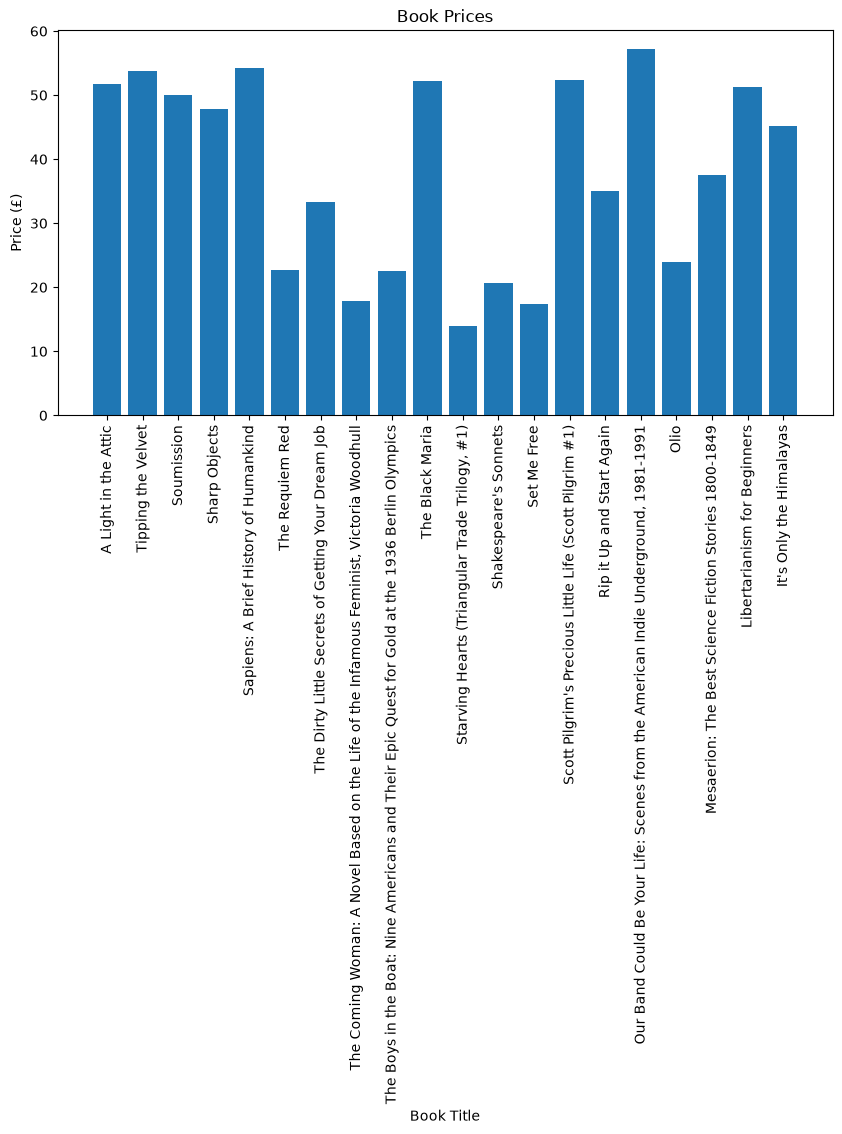

In [17]:
plt.figure(figsize=(10,5))

plt.bar(df["Title"], df["Price"])

plt.title("Book Prices")
plt.xlabel("Book Title")
plt.ylabel("Price (£)")

plt.xticks(rotation=90)

plt.show()

In [18]:
df["Availability"].value_counts()

Availability
In stock    20
Name: count, dtype: int64

In [19]:
top_5 = df.sort_values("Price", ascending=False).head(5)

top_5

,Title,Price,Availability
15,Our Band Could Be Your Life: Scenes from the A...,57.25,In stock
4,Sapiens: A Brief History of Humankind,54.23,In stock
1,Tipping the Velvet,53.74,In stock
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,In stock
9,The Black Maria,52.15,In stock


In [20]:
bottom_5 = df.sort_values("Price", ascending=True).head(5)

bottom_5

,Title,Price,Availability
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,In stock
12,Set Me Free,17.46,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,In stock
11,Shakespeare's Sonnets,20.66,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,In stock


In [21]:
df.to_csv("scraped_data.csv", index=False)

# Key Findings

1. The website contains 20 books on the first page.

2. Book titles, prices, and availability were successfully extracted using web scraping.

3. The average book price was calculated from the scraped data.

4. The scraped books were available in stock on the first page.

5. Book prices vary across different titles, which can be observed from the price visualization.

# Conclusion

This project demonstrates web scraping using Python.

The Requests library was used to access the website, and BeautifulSoup was used to extract book information.

The scraped data was converted into a Pandas DataFrame and saved as a CSV file.

The analysis and visualization helped understand book prices and availability.